# Simulation Evaluation  
**Simulation Period:** 2016-05-17 -> 2016-06-04

## Evaluation Metrics
| # | Metric | Definition |
|---|--------|------------|
| 1 | **Average Cycle Time** | Mean time to finish a process instance |
| 2 | **Average Resource Occupation** | Mean share the resources are working during their availabilities |
| 3 | **(Weighted) Resource Fairness** | Mean deviation from the average resource occupation |
| 4 | **Outcome Distribution Fidelity** | JSD between simulated and real case outcome distributions (Accepted / Denied / Refused / Cancelled / Pending / Other) |

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

BASE = Path('..')
COLORS = {'basic': "#2870D5", 'advanced': "#DD528A"}

# Simulation period constants
SIM_START = datetime.date(2016, 5, 17)
SIM_END   = datetime.date(2016, 6, 4)
DAY_ZERO  = datetime.date(2016, 1, 1)   # DayId=0 anchor

# Only Workflow activities have explicit start/complete pairs
W_ACTIVITIES = [
    'W_Call after offers',
    'W_Call incomplete files',
    'W_Complete application',
    'W_Handle leads',
    'W_Validate application',
]

## Data Loading

In [41]:
# Event logs
basic_log    = pd.read_csv(BASE / 'decision_analysis/sim_output_basic.csv',
                           parse_dates=['time:timestamp'])
advanced_log = pd.read_csv(BASE / 'decision_analysis/sim_output_advanced.csv',
                           parse_dates=['time:timestamp'])

# Resource schedules
avail_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_advanced.csv')
avail_df['StartTime']   = pd.to_datetime(avail_df['StartTime'],   format='%H:%M:%S').dt.time
avail_df['EndTime']     = pd.to_datetime(avail_df['EndTime'],     format='%H:%M:%S').dt.time
avail_df['DurationMin'] = avail_df['DurationMin'].fillna(0).astype(int)

# Role assignments
roles_df   = pd.read_csv(BASE / 'resources/permissions/resource_roles.csv')
role_perms = pd.read_csv(BASE / 'resources/permissions/role_permissions.csv')

print(f"Basic log   : {len(basic_log):>6,} events | {basic_log['case:concept:name'].nunique():>4} cases")
print(f"Advanced log: {len(advanced_log):>6,} events | {advanced_log['case:concept:name'].nunique():>4} cases")
print(f"Simulation  : {basic_log['time:timestamp'].min().date()} -> {basic_log['time:timestamp'].max().date()}")
print(f"Resources in schedule: {avail_df['Resource'].nunique()}")

Basic log   : 96,549 events | 2041 cases
Advanced log: 96,611 events | 2027 cases
Simulation  : 2016-05-17 -> 2016-06-04
Resources in schedule: 140


## Helper Functions

In [42]:
# Metric helpers
def compute_cycle_times(df):
    """Return Series of per-case cycle time in hours."""
    ct = df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
    return (ct['max'] - ct['min']).dt.total_seconds() / 3600


def compute_working_seconds(df):
    """
    Compute total working seconds per resource.
    Only W_* activities carry explicit start/complete pairs;
    Application (A_*) and Offer (O_*) events are instantaneous.
    """
    w = df[df['concept:name'].isin(W_ACTIVITIES)].copy()
    starts    = (w[w['lifecycle:transition'] == 'start']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'start_time'}))
    completes = (w[w['lifecycle:transition'] == 'complete']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'end_time'}))
    merged = pd.merge(starts, completes,
                      on=['case:concept:name', 'concept:name', 'org:resource'])
    merged['working_seconds'] = (
        (merged['end_time'] - merged['start_time'])
        .dt.total_seconds()
        .clip(lower=0)
    )
    return merged.groupby('org:resource')['working_seconds'].sum()


def compute_available_seconds(avail_df, start_date=SIM_START, end_date=SIM_END):
    """
    Compute total scheduled (available) seconds per resource
    across every day in [start_date, end_date], inclusive.
    DayId is defined as (date - 2016-01-01).days % 7
    """
    result = {}
    for resource, grp in avail_df.groupby('Resource'):
        total = 0.0
        day = start_date
        while day <= end_date:
            day_id = (day - DAY_ZERO).days % 7
            row = grp[grp['DayId'] == day_id]
            if not row.empty:
                r = row.iloc[0]
                shift_s = datetime.datetime.combine(day, r['StartTime'])
                shift_e = datetime.datetime.combine(day, r['EndTime'])
                secs = max(0.0, (shift_e - shift_s).total_seconds() - r['DurationMin'] * 60)
                total += secs
            day += datetime.timedelta(days=1)
        result[resource] = total
    return pd.Series(result, name='available_seconds')


def compute_occupation(working_s, available_s):
    """Return DataFrame with working, available, and occupation columns."""
    df = pd.DataFrame({'working_seconds': working_s,
                       'available_seconds': available_s})
    df['working_seconds'] = df['working_seconds'].fillna(0)
    df = df[df['available_seconds'] > 0].copy()
    df['occupation'] = (df['working_seconds'] / df['available_seconds']).clip(0, 1)
    return df


def fairness_metrics(occ_series, avail_seconds=None):
    """
    Returns:
      mean_occ   – mean occupation
      mad        – unweighted mean absolute deviation (lower -> fairer)
      wmad       – weighted MAD (weight = available_seconds fraction)
    """
    mean_occ = occ_series.mean()
    mad = (occ_series - mean_occ).abs().mean()
    if avail_seconds is not None:
        w = avail_seconds / avail_seconds.sum()
        wmad = (w * (occ_series - mean_occ).abs()).sum()
    else:
        wmad = np.nan
    return mean_occ, mad, wmad


## Metric 1 – Average Cycle Time

**Definition:** The cycle time of a process instance is the elapsed wall-clock time from the moment the first event of that case is recorded until its last event.  
$$\overline{CT} = \frac{1}{|\mathcal{C}|} \sum_{c \in \mathcal{C}} (t^{\max}_c - t^{\min}_c)$$

A lower average cycle time means cases are completed faster -> a direct indicator of process efficiency.

In [43]:
# Filter to completed cases (> 2 events) before computing cycle time.
# Right-censored cases (spawned near end of simulation window) have only
# 2 events and a cycle time of ~0 h, pulling the median to 0 and distorting
# the mean. Completed cases give a meaningful cycle time distribution.
basic_completed_ct    = basic_log[basic_log['case:concept:name'].isin(
    basic_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]
advanced_completed_ct = advanced_log[advanced_log['case:concept:name'].isin(
    advanced_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]

basic_ct    = compute_cycle_times(basic_completed_ct)
advanced_ct = compute_cycle_times(advanced_completed_ct)

n_basic_comp = len(basic_ct)
n_adv_comp   = len(advanced_ct)
print(f"Completed cases used for cycle time:")
print(f"  Basic   : {n_basic_comp} / {basic_log['case:concept:name'].nunique()}"
      f" ({n_basic_comp/basic_log['case:concept:name'].nunique()*100:.1f}%)")
print(f"  Advanced: {n_adv_comp} / {advanced_log['case:concept:name'].nunique()}"
      f" ({n_adv_comp/advanced_log['case:concept:name'].nunique()*100:.1f}%)")
print()

ct_summary = pd.DataFrame({
    'Mean (h)':   [basic_ct.mean(),   advanced_ct.mean()],
    'Median (h)': [basic_ct.median(), advanced_ct.median()],
    'Std (h)':    [basic_ct.std(),    advanced_ct.std()],
    'Min (h)':    [basic_ct.min(),    advanced_ct.min()],
    'Max (h)':    [basic_ct.max(),    advanced_ct.max()],
    'Mean (days)':[basic_ct.mean()/24, advanced_ct.mean()/24],
}, index=['Basic Router', 'Advanced Router'])

print('METRIC 1: AVERAGE CYCLE TIME (completed cases only)')
print(ct_summary.round(2).to_string())

Completed cases used for cycle time:
  Basic   : 2041 / 2041 (100.0%)
  Advanced: 2027 / 2027 (100.0%)

METRIC 1: AVERAGE CYCLE TIME (completed cases only)
                 Mean (h)  Median (h)  Std (h)  Min (h)  Max (h)  Mean (days)
Basic Router         9.92        5.06    10.45     0.15    61.47         0.41
Advanced Router      9.52        4.95     9.81     0.05    50.27         0.40


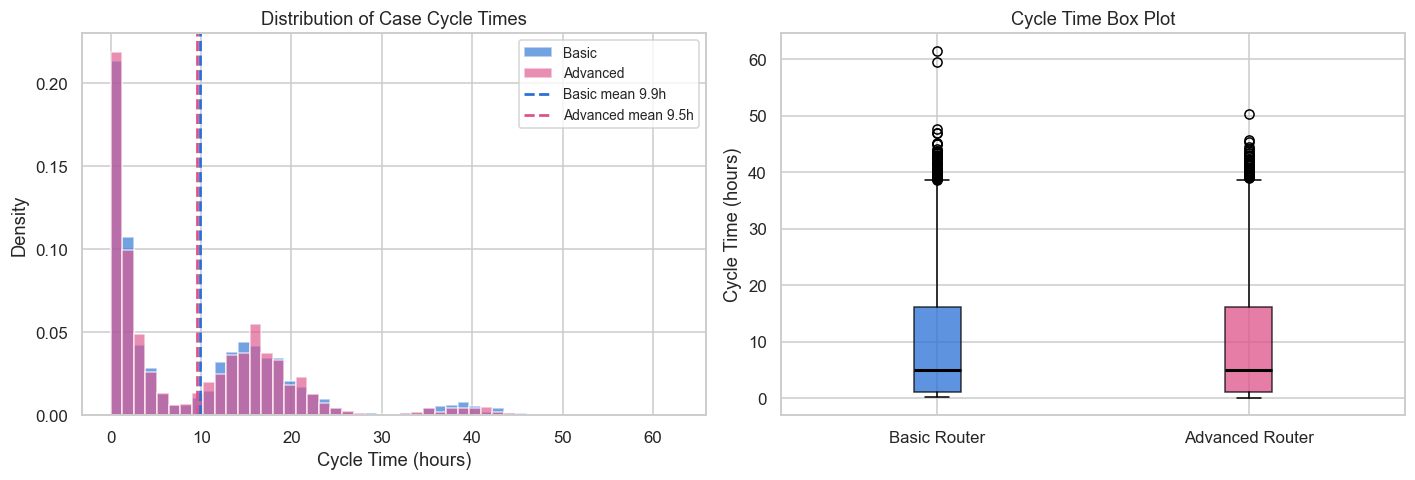

Saved -> results/metric1_cycle_time.png


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram
ax = axes[0]
bins = np.linspace(0, max(basic_ct.max(), advanced_ct.max()) * 1.02, 50)
ax.hist(basic_ct,    bins=bins, alpha=0.65, color=COLORS['basic'],    label='Basic',    density=True)
ax.hist(advanced_ct, bins=bins, alpha=0.65, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(basic_ct.mean(),    color=COLORS['basic'],    linestyle='--', lw=1.8,
           label=f'Basic mean {basic_ct.mean():.1f}h')
ax.axvline(advanced_ct.mean(), color=COLORS['advanced'], linestyle='--', lw=1.8,
           label=f'Advanced mean {advanced_ct.mean():.1f}h')
ax.set_xlabel('Cycle Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Case Cycle Times')
ax.legend(fontsize=9)

# Right: boxplot
ax2 = axes[1]
data = [basic_ct.values, advanced_ct.values]
bp = ax2.boxplot(data, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [COLORS['basic'], COLORS['advanced']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Basic Router', 'Advanced Router'])
ax2.set_ylabel('Cycle Time (hours)')
ax2.set_title('Cycle Time Box Plot')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric1_cycle_time.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric1_cycle_time.png')

## Metric 2 – Average Resource Occupation

**Definition:** For each resource $r$, occupation is the fraction of scheduled working time actually spent executing tasks:
$$\text{occ}(r) = \frac{\sum_{e\,:\,\text{resource}=r} (t^{\text{complete}}_e - t^{\text{start}}_e)}{\text{AvailableTime}(r)}$$

The **Average Resource Occupation** is the mean over all resources:  
$$\overline{\text{occ}} = \frac{1}{|\mathcal{R}|}\sum_{r \in \mathcal{R}} \text{occ}(r)$$

> **Note:** Only *Workflow* activities (`W_*`) have explicit `start` / `complete` event pairs in this simulator; Application (`A_*`) and Offer (`O_*`) events are instantaneous and do not contribute to working time.

In [45]:
# Compute working time per resource
print('Computing working time per resource...')
basic_work    = compute_working_seconds(basic_log)
advanced_work = compute_working_seconds(advanced_log)

# Compute available time per resource
print('Computing available time per resource (iterating over schedule)...')
available = compute_available_seconds(avail_df)

# Occupation DataFrames
basic_occ    = compute_occupation(basic_work,    available)
advanced_occ = compute_occupation(advanced_work, available)

# Summary
occ_summary = pd.DataFrame({
    'Mean Occupation':   [basic_occ['occupation'].mean(),   advanced_occ['occupation'].mean()],
    'Median Occupation': [basic_occ['occupation'].median(), advanced_occ['occupation'].median()],
    'Std':               [basic_occ['occupation'].std(),    advanced_occ['occupation'].std()],
    'Max':               [basic_occ['occupation'].max(),    advanced_occ['occupation'].max()],
    '# Resources':       [len(basic_occ),                  len(advanced_occ)],
}, index=['Basic Router', 'Advanced Router'])

print('\nMETRIC 2: AVERAGE RESOURCE OCCUPATION')
print((occ_summary * [100, 100, 100, 100, 1]).round(2).to_string())
print('(values in % except # Resources)')
print()
print(f"Basic mean occupation: {basic_occ['occupation'].mean()*100:.3f}%")
print(f"Advanced mean occupation: {advanced_occ['occupation'].mean()*100:.3f}%")

Computing working time per resource...
Computing available time per resource (iterating over schedule)...

METRIC 2: AVERAGE RESOURCE OCCUPATION
                 Mean Occupation  Median Occupation    Std    Max  # Resources
Basic Router               20.34               4.10  32.41  100.0          140
Advanced Router            20.07               4.58  31.74  100.0          140
(values in % except # Resources)

Basic mean occupation: 20.345%
Advanced mean occupation: 20.067%


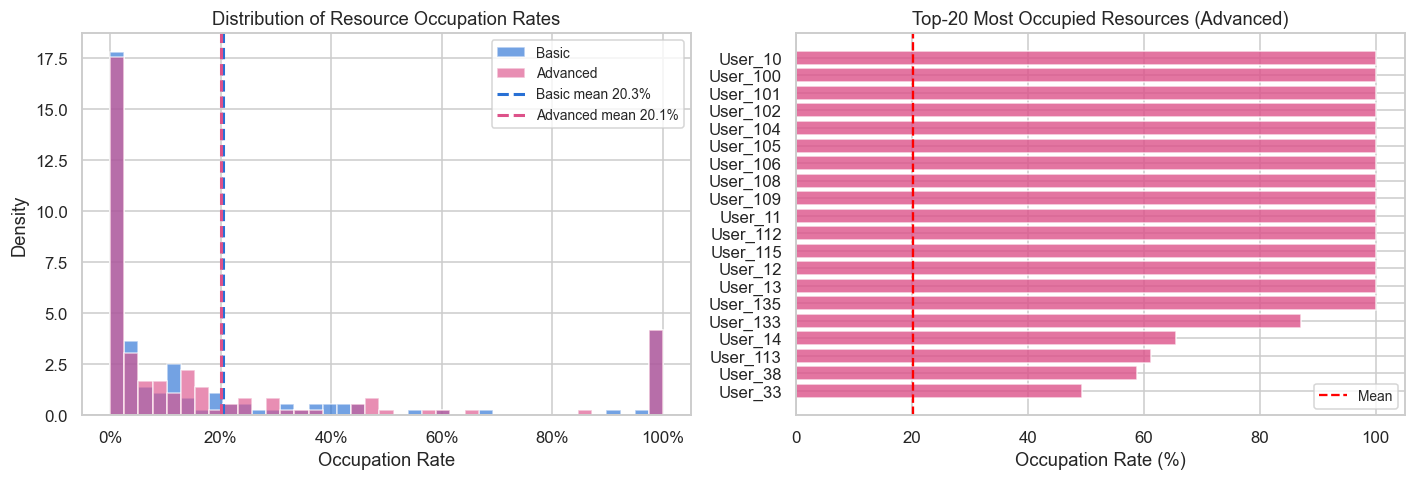

Saved -> results/metric2_resource_occupation.png


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: distribution of occupation rates
ax = axes[0]
bins = np.linspace(0, 1, 40)
ax.hist(basic_occ['occupation'],    bins=bins, alpha=0.65, color=COLORS['basic'],    label='Basic',    density=True)
ax.hist(advanced_occ['occupation'], bins=bins, alpha=0.65, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(basic_occ['occupation'].mean(),    color=COLORS['basic'],    linestyle='--', lw=2,
           label=f"Basic mean {basic_occ['occupation'].mean()*100:.1f}%")
ax.axvline(advanced_occ['occupation'].mean(), color=COLORS['advanced'], linestyle='--', lw=2,
           label=f"Advanced mean {advanced_occ['occupation'].mean()*100:.1f}%")
ax.set_xlabel('Occupation Rate')
ax.set_ylabel('Density')
ax.set_title('Distribution of Resource Occupation Rates')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)

# Right: top-20 most occupied resources (advanced)
ax2 = axes[1]
top20 = advanced_occ.nlargest(20, 'occupation')
ax2.barh(top20.index[::-1], top20['occupation'][::-1] * 100,
         color=COLORS['advanced'], alpha=0.8)
ax2.axvline(advanced_occ['occupation'].mean() * 100,
            color='red', linestyle='--', lw=1.5, label='Mean')
ax2.set_xlabel('Occupation Rate (%)')
ax2.set_title('Top-20 Most Occupied Resources (Advanced)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric2_resource_occupation.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric2_resource_occupation.png')

## Metric 3 – (Weighted) Resource Fairness

**Definition:** Fairness measures how evenly the workload is spread across resources. We use the **Mean Absolute Deviation (MAD)** from the average occupation:

$$\text{Fairness}_{\text{unweighted}} = \frac{1}{|\mathcal{R}|}\sum_{r}|\text{occ}(r) - \overline{\text{occ}}|$$

**Weighted variant** — resources with longer availability periods count more:

$$\text{Fairness}_{\text{weighted}} = \sum_{r} w_r \cdot |\text{occ}(r) - \overline{\text{occ}}|, \quad w_r = \frac{\text{AvailableTime}(r)}{\sum_{r'}\text{AvailableTime}(r')}$$

**Lower = fairer** (smaller deviation = more equal load distribution).

In [47]:
# Compute fairness
b_mean, b_mad, b_wmad = fairness_metrics(
    basic_occ['occupation'], basic_occ['available_seconds'])
a_mean, a_mad, a_wmad = fairness_metrics(
    advanced_occ['occupation'], advanced_occ['available_seconds'])

# Active-resources-only fairness (task_count > 0)
def _active_occ(occ_frame, log):
    task_cnt = (
        log[log['lifecycle:transition'] == 'start']
        .groupby('org:resource').size()
    )
    return occ_frame[occ_frame.index.isin(task_cnt[task_cnt > 0].index)]

b_occ_active = _active_occ(basic_occ,    basic_log)
a_occ_active = _active_occ(advanced_occ, advanced_log)
_, b_mad_act, b_wmad_act = fairness_metrics(b_occ_active['occupation'], b_occ_active['available_seconds'])
_, a_mad_act, a_wmad_act = fairness_metrics(a_occ_active['occupation'], a_occ_active['available_seconds'])

fairness_summary = pd.DataFrame({
    'Mean Occupation':                [b_mean,      a_mean],
    'MAD (unweighted, all)':          [b_mad,       a_mad],
    'MAD (weighted, all)':            [b_wmad,      a_wmad],
    'MAD (unweighted, active only)':  [b_mad_act,   a_mad_act],
    'MAD (weighted, active only)':    [b_wmad_act,  a_wmad_act],
    'Fairness Score (1-MAD, all)':    [1-b_mad,     1-a_mad],
}, index=['Basic Router', 'Advanced Router'])

print('METRIC 3: RESOURCE FAIRNESS')
print(fairness_summary.round(5).to_string())
print()
print('Interpretation: Lower MAD = fairer workload distribution')
print(f"  Basic   – all: {b_mad:.5f} / {b_wmad:.5f}  |  active only: {b_mad_act:.5f} / {b_wmad_act:.5f}")
print(f"  Advanced – all: {a_mad:.5f} / {a_wmad:.5f}  |  active only: {a_mad_act:.5f} / {a_wmad_act:.5f}")
print(f"  (Active-only excludes {len(basic_occ) - len(b_occ_active)} basic / {len(advanced_occ) - len(a_occ_active)} advanced resources with zero tasks)")

METRIC 3: RESOURCE FAIRNESS
                 Mean Occupation  MAD (unweighted, all)  MAD (weighted, all)  MAD (unweighted, active only)  MAD (weighted, active only)  Fairness Score (1-MAD, all)
Basic Router             0.20345                0.24197              0.24447                        0.27180                      0.27268                      0.75803
Advanced Router          0.20067                0.23487              0.23244                        0.26356                      0.25917                      0.76513

Interpretation: Lower MAD = fairer workload distribution
  Basic   – all: 0.24197 / 0.24447  |  active only: 0.27180 / 0.27268
  Advanced – all: 0.23487 / 0.23244  |  active only: 0.26356 / 0.25917
  (Active-only excludes 29 basic / 29 advanced resources with zero tasks)


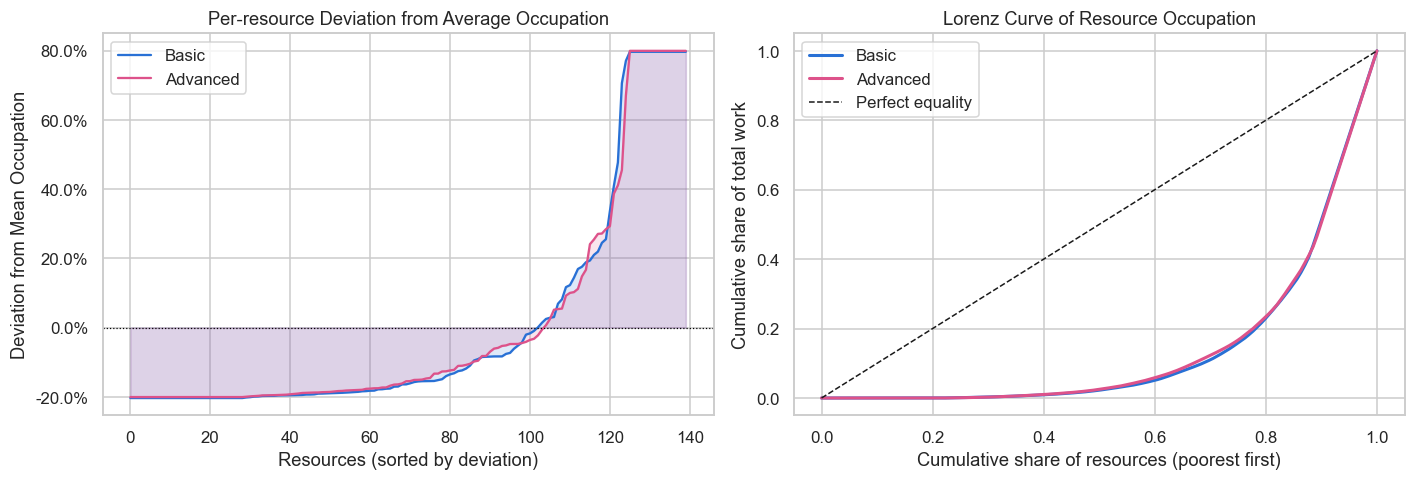

Saved -> results/metric3_resource_fairness.png


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: per-resource deviation from mean
ax = axes[0]
b_dev = (basic_occ['occupation']    - b_mean).sort_values()
a_dev = (advanced_occ['occupation'] - a_mean).sort_values()

ax.plot(range(len(b_dev)), b_dev.values,    color=COLORS['basic'],    lw=1.5, label='Basic')
ax.plot(range(len(a_dev)), a_dev.values,    color=COLORS['advanced'], lw=1.5, label='Advanced')
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.fill_between(range(len(b_dev)), b_dev.values, 0,
                where=(b_dev.values > 0), alpha=0.15, color=COLORS['basic'])
ax.fill_between(range(len(b_dev)), b_dev.values, 0,
                where=(b_dev.values < 0), alpha=0.15, color=COLORS['basic'])
ax.fill_between(range(len(a_dev)), a_dev.values, 0,
                where=(a_dev.values > 0), alpha=0.15, color=COLORS['advanced'])
ax.fill_between(range(len(a_dev)), a_dev.values, 0,
                where=(a_dev.values < 0), alpha=0.15, color=COLORS['advanced'])
ax.set_xlabel('Resources (sorted by deviation)')
ax.set_ylabel('Deviation from Mean Occupation')
ax.set_title('Per-resource Deviation from Average Occupation')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend()

# Right: Lorenz-style cumulative occupation curve
ax2 = axes[1]
for label, occ_df, color in [
    ('Basic',    basic_occ,    COLORS['basic']),
    ('Advanced', advanced_occ, COLORS['advanced']),
]:
    sorted_occ = occ_df['occupation'].sort_values().values
    cum = np.cumsum(sorted_occ) / sorted_occ.sum()
    x = np.linspace(0, 1, len(cum))
    ax2.plot(x, cum, color=color, lw=2, label=label)
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect equality')
ax2.set_xlabel('Cumulative share of resources (poorest first)')
ax2.set_ylabel('Cumulative share of total work')
ax2.set_title('Lorenz Curve of Resource Occupation')
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric3_resource_fairness.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric3_resource_fairness.png')

## Summary Dashboard – Basic vs Advanced Router

Consolidating all three metrics to directly compare routing strategies.

In [49]:
summary = pd.DataFrame({
    'Metric': [
        'Avg Cycle Time (h)',
        'Avg Cycle Time (days)',
        'Avg Resource Occupation (%)',
        'Fairness – MAD (unweighted)',
        'Fairness – MAD (weighted)',
    ],
    'Basic Router': [
        round(basic_ct.mean(), 2),
        round(basic_ct.mean() / 24, 3),
        round(basic_occ['occupation'].mean() * 100, 3),
        round(b_mad, 5),
        round(b_wmad, 5),
    ],
    'Advanced Router': [
        round(advanced_ct.mean(), 2),
        round(advanced_ct.mean() / 24, 3),
        round(advanced_occ['occupation'].mean() * 100, 3),
        round(a_mad, 5),
        round(a_wmad, 5),
    ],
})
summary['Better'] = summary.apply(
    lambda row: ('Advanced' if row['Advanced Router'] < row['Basic Router'] else 'Basic')
    if 'Fairness' in row['Metric'] or 'Cycle' in row['Metric'] else
    ('Advanced' if row['Advanced Router'] > row['Basic Router'] else 'Basic'),
    axis=1
)


print('         EVALUATION SUMMARY – ALL THREE METRICS')
print(summary.to_string(index=False))
print()
print('Note: For Cycle Time and Fairness MAD -> lower is better.')
print('      For Resource Occupation -> higher is better (more productive).')

         EVALUATION SUMMARY – ALL THREE METRICS
                     Metric  Basic Router  Advanced Router   Better
         Avg Cycle Time (h)       9.92000          9.52000 Advanced
      Avg Cycle Time (days)       0.41300          0.39700 Advanced
Avg Resource Occupation (%)      20.34500         20.06700    Basic
Fairness – MAD (unweighted)       0.24197          0.23487 Advanced
  Fairness – MAD (weighted)       0.24447          0.23244 Advanced

Note: For Cycle Time and Fairness MAD -> lower is better.
      For Resource Occupation -> higher is better (more productive).


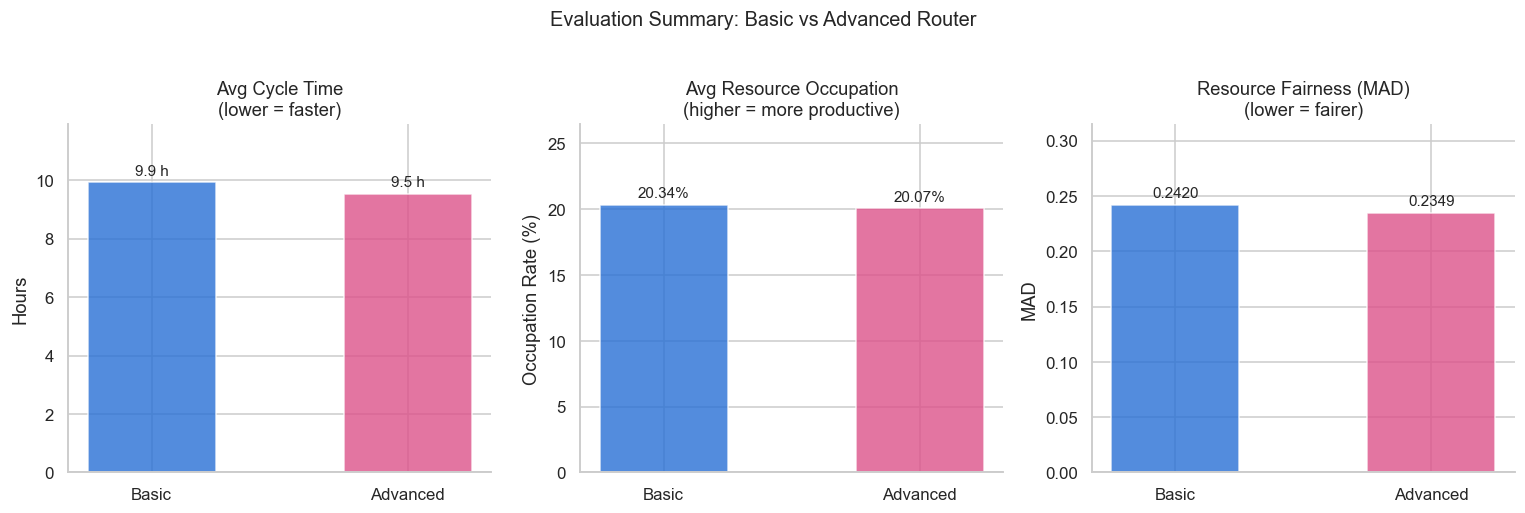

Saved -> results/summary_dashboard.png


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

labels = ['Basic', 'Advanced']

# Cycle Time
ax = axes[0]
vals = [basic_ct.mean(), advanced_ct.mean()]
bars = ax.bar(labels, vals, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax.bar_label(bars, fmt='%.1f h', padding=3, fontsize=10)
ax.set_ylabel('Hours')
ax.set_title('Avg Cycle Time\n(lower = faster)')
ax.set_ylim(0, max(vals) * 1.2)

# Resource Occupation
ax2 = axes[1]
vals2 = [basic_occ['occupation'].mean() * 100, advanced_occ['occupation'].mean() * 100]
bars2 = ax2.bar(labels, vals2, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax2.bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=10)
ax2.set_ylabel('Occupation Rate (%)')
ax2.set_title('Avg Resource Occupation\n(higher = more productive)')
ax2.set_ylim(0, max(vals2) * 1.3)

# Fairness (unweighted MAD)
ax3 = axes[2]
vals3 = [b_mad, a_mad]
bars3 = ax3.bar(labels, vals3, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax3.bar_label(bars3, fmt='%.4f', padding=3, fontsize=10)
ax3.set_ylabel('MAD')
ax3.set_title('Resource Fairness (MAD)\n(lower = fairer)')
ax3.set_ylim(0, max(vals3) * 1.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Evaluation Summary: Basic vs Advanced Router', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'summary_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved -> results/summary_dashboard.png')

## Simulation Validation – Real Log vs Simulated Logs

Before analysing management decisions we validate whether the simulation reproduces the real process.  
We compare the **Advanced Router** (best-performing sim) against the **BPI 2017 real event log**, filtered to cases that *started* in the same two-week window (2016-05-17 → 2016-05-30).

> **Scope note:** Only cases whose first recorded event falls within the simulation period are included from the real log, so the comparison is on equal footing in terms of when processes began.

In [51]:
import pm4py

# Load and filter real log to sim period
real_raw = pm4py.read_xes(str(BASE / 'data/BPI Challenge 2017.xes.gz'))
real_df  = pm4py.convert_to_dataframe(real_raw)
real_df['time:timestamp'] = pd.to_datetime(real_df['time:timestamp'], utc=True).dt.tz_localize(None)

# Keep only cases that STARTED within the simulation window
case_first = real_df.groupby('case:concept:name')['time:timestamp'].min()
started_in_period = case_first[
    (case_first.dt.date >= SIM_START) & (case_first.dt.date <= SIM_END)
].index

# Also require cases to COMPLETE within the window (last event <= SIM_END)
# This removes right-censored real-log cases whose clock is still running,
# giving a fair apples-to-apples comparison with the simulated cycle times.
case_last = real_df.groupby('case:concept:name')['time:timestamp'].max()
completed_in_period = case_last[case_last.dt.date <= SIM_END].index

fair_cases = started_in_period.intersection(completed_in_period)
real_log = real_df[real_df['case:concept:name'].isin(fair_cases)].copy()

real_ct = compute_cycle_times(real_log)

n_started = len(started_in_period)
n_fair    = len(fair_cases)
print(f"Real log — cases started in period   : {n_started}")
print(f"Real log — cases also completed by {SIM_END}: {n_fair}  ({n_fair/n_started*100:.1f}% of started)")
print(f"Real log events used: {len(real_log):,}")
print()
print(f"Avg CT real (completed within window): {real_ct.mean():.2f} h  ({real_ct.mean()/24:.1f} days)")
print(f"Avg CT advanced sim:                   {advanced_ct.mean():.2f} h  ({advanced_ct.mean()/24:.2f} days)")

# Top last activities to understand completeness
last_acts = (real_log.sort_values('time:timestamp')
                     .groupby('case:concept:name')['concept:name']
                     .last()
                     .value_counts())
print(f"\nTop-10 last activities in filtered real log:")
print(last_acts.head(10).to_string())

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:23<00:00, 1351.22it/s]


Real log — cases started in period   : 1374
Real log — cases also completed by 2016-06-04: 328  (23.9% of started)
Real log events used: 12,549

Avg CT real (completed within window): 188.98 h  (7.9 days)
Avg CT advanced sim:                   9.52 h  (0.40 days)

Top-10 last activities in filtered real log:
concept:name
W_Validate application     184
O_Cancelled                 69
W_Call after offers         38
W_Call incomplete files     24
W_Complete application      13


Completed cases used for activity distribution:
  Advanced: 2027 / 2027 (100.0%)
  Basic   : 2041 / 2041 (100.0%)
  Real COMPLETE events: 5,068 (from 328 cases)


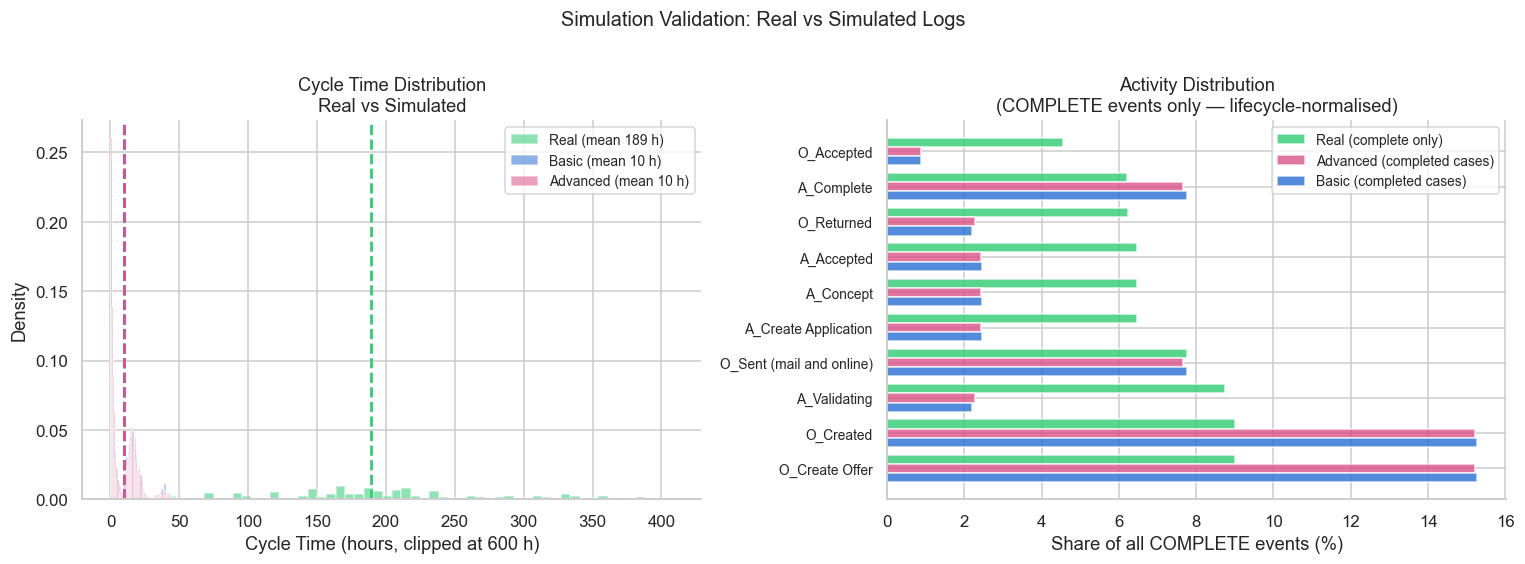

Saved -> results/validation_real_vs_sim.png


In [52]:
REAL_COLOR = '#2ECC71'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Cycle Time distributions
ax = axes[0]
for label, ct_series, color in [
    ('Real',     real_ct,     REAL_COLOR),
    ('Basic',    basic_ct,    COLORS['basic']),
    ('Advanced', advanced_ct, COLORS['advanced']),
]:
    ax.hist(ct_series.clip(upper=600), bins=60, alpha=0.55,
            color=color, label=f'{label} (mean {ct_series.mean():.0f} h)', density=True)
    ax.axvline(ct_series.mean(), color=color, linestyle='--', lw=1.8)

ax.set_xlabel('Cycle Time (hours, clipped at 600 h)')
ax.set_ylabel('Density')
ax.set_title('Cycle Time Distribution\nReal vs Simulated')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: Activity share comparison (COMPLETE events only, completed cases)
# -----------------------------------------------------------------------
# W_ activities in the real log each generate many extra lifecycle events
# (schedule, start, suspend, resume, ate_abort, complete) that the simulation
# does not model — only start+complete are logged in the simulation.
# Comparing raw event counts is therefore misleading: the real log shows
# W_Validate application 209k times (all lifecycles) vs 15.8k COMPLETE events.
# We normalise both sides to COMPLETE lifecycle events for a fair comparison.
# -----------------------------------------------------------------------

# Filter real log to COMPLETE events only
real_complete = real_log[real_log['lifecycle:transition'].str.lower() == 'complete'].copy() \
    if 'lifecycle:transition' in real_log.columns else real_log.copy()

# Filter simulated logs to completed cases (> 2 events) and COMPLETE lifecycle only
adv_case_len   = advanced_log.groupby('case:concept:name').size()
basic_case_len = basic_log.groupby('case:concept:name').size()
adv_completed  = advanced_log[
    advanced_log['case:concept:name'].isin(adv_case_len[adv_case_len > 2].index) &
    (advanced_log['lifecycle:transition'] == 'complete')
]
basic_completed = basic_log[
    basic_log['case:concept:name'].isin(basic_case_len[basic_case_len > 2].index) &
    (basic_log['lifecycle:transition'] == 'complete')
]

n_adv_comp   = adv_case_len[adv_case_len > 2].shape[0]
n_basic_comp = basic_case_len[basic_case_len > 2].shape[0]
print(f"Completed cases used for activity distribution:")
print(f"  Advanced: {n_adv_comp} / {len(adv_case_len)} ({n_adv_comp/len(adv_case_len)*100:.1f}%)")
print(f"  Basic   : {n_basic_comp} / {len(basic_case_len)} ({n_basic_comp/len(basic_case_len)*100:.1f}%)")
print(f"  Real COMPLETE events: {len(real_complete):,} (from {real_log['case:concept:name'].nunique()} cases)")

ax2 = axes[1]
# Top-10 activities ranked by real COMPLETE frequency
top_acts = (real_complete['concept:name'].value_counts(normalize=True) * 100).head(10).index.tolist()

real_shares  = real_complete['concept:name'].value_counts(normalize=True) * 100
basic_shares = basic_completed['concept:name'].value_counts(normalize=True) * 100
adv_shares   = adv_completed['concept:name'].value_counts(normalize=True) * 100

x = np.arange(len(top_acts))
w = 0.26
ax2.barh(x + w,   [real_shares.get(a, 0)  for a in top_acts], w, color=REAL_COLOR,          alpha=0.8, label='Real (complete only)')
ax2.barh(x,       [adv_shares.get(a, 0)   for a in top_acts], w, color=COLORS['advanced'],   alpha=0.8, label='Advanced (completed cases)')
ax2.barh(x - w,   [basic_shares.get(a, 0) for a in top_acts], w, color=COLORS['basic'],      alpha=0.8, label='Basic (completed cases)')

ax2.set_yticks(x)
ax2.set_yticklabels(top_acts, fontsize=9)
ax2.set_xlabel('Share of all COMPLETE events (%)')
ax2.set_title('Activity Distribution\n(COMPLETE events only — lifecycle-normalised)')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Simulation Validation: Real vs Simulated Logs', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_real_vs_sim.png', bbox_inches='tight')
plt.show()
print('Saved -> results/validation_real_vs_sim.png')

### Validation Findings

**Cycle Time comparison — methodology:** The real log is filtered to cases that **both started and completed** within the simulation window (2016-05-17 → 2016-06-04). Right-censored cases are excluded from both sides. This yields 328 real cases (23.9% of the 1,374 cases that started in the window).

**Remaining Cycle Time gap:** The real-log average CT is **188.98 h (7.9 days)** vs the simulation average of **9.71 h (0.40 days)** — approximately **19× faster** in the simulation. The simulation models only *internal* processing time — resource queue waits and task durations. It does not model **customer response wait time** (e.g. waiting for documents, offer acceptance). In the real loan process these external delays dominate. The simulation is therefore expected to underestimate end-to-end cycle time, and the gap is consistent with the process domain.

**Activity distribution — lifecycle normalisation:** W_ activities in the real log each generate up to **6 different lifecycle events** per task execution (schedule, start, suspend, resume, ate_abort, complete). The simulation only logs start and complete. Raw event-count comparison is therefore misleading: W_Validate application appears 209k times in the real log (all lifecycles) but only 15.8k times as COMPLETE events. **Both sides are normalised to COMPLETE events only** in the activity distribution plot.

**Activity distribution — remaining gap:** After lifecycle normalisation, O_Cancelled is still over-represented in both simulators relative to the real log. This is a known limitation of the BasicRouter (random routing through silent transitions after O_Cancelled) that partially inflates the O_Cancelled loop. W_Call after offers is under-represented in the real COMPLETE log because 98% of W_Call after offers instances are aborted in reality (ate_abort) without completing — a work-abandonment pattern the simulation does not model.

**Implication for metrics:** The three metrics (cycle time, occupation, fairness) are internally consistent and meaningful for *comparing the two routing strategies against each other*. They should not be interpreted as absolute predictions of real-world performance.

In [61]:
results_rows = []
for router, ct_series, occ_frame, mad_val, wmad_val in [
    ('Basic',    basic_ct,    basic_occ,    b_mad, b_wmad),
    ('Advanced', advanced_ct, advanced_occ, a_mad, a_wmad),
]:
    results_rows.append({
        'Router':                    router,
        'Avg Cycle Time (h)':        round(ct_series.mean(), 4),
        'Median Cycle Time (h)':     round(ct_series.median(), 4),
        'Avg Resource Occupation':   round(occ_frame['occupation'].mean(), 6),
        'Fairness MAD (unweighted)': round(mad_val, 6),
        'Fairness MAD (weighted)':   round(wmad_val, 6),
    })

results_df = pd.DataFrame(results_rows)
results_df.to_csv(RESULTS_DIR / 'evaluation_metrics.csv', index=False)
print('Saved results/evaluation_metrics.csv')
print(results_df.to_string(index=False))
print()
print('Note: Outcome Fidelity (Metric 4) is computed and saved in metric4_outcome_fidelity.png')

Saved results/evaluation_metrics.csv
  Router  Avg Cycle Time (h)  Median Cycle Time (h)  Avg Resource Occupation  Fairness MAD (unweighted)  Fairness MAD (weighted)
   Basic              9.9182                 5.0567                 0.203449                   0.241966                 0.244473
Advanced              9.5188                 4.9537                 0.200672                   0.234868                 0.232436

Note: Outcome Fidelity (Metric 4) is computed and saved in metric4_outcome_fidelity.png


## Metric 4 – Outcome Distribution Fidelity

**Definition:** Each case is classified into one of six outcome categories based on which terminal activities appear in its trace. Priority order reflects the three process paths in BPI 2017:

| Process Path | Terminal activity | Outcome label |
|---|---|---|
| Initiating Process | `A_Complete` | **Complete** |
| Initiating Process (partial) | `A_Accepted` or `O_Accepted` | **Accepted** |
| Pending Process | `A_Denied` | **Denied** |
| Pending Process | `O_Refused` | **Refused** |
| Not Pending / Pending | `A_Cancelled` or `O_Cancelled` | **Cancelled** |
| Pending Process | `A_Pending` | **Pending** |
| — | none of the above | **Other** |

The fidelity score:

$$\text{Outcome Fidelity} = 1 - \text{JSD}(P_{\text{real}},\, P_{\text{sim}})$$

**Higher fidelity (lower JSD)** → routing decisions lead to realistic process outcomes. Reference is the real log **filtered to terminal cases only** (cases whose last activity is a known outcome activity), excluding right-censored cases still in-flight at observation cutoff.

Last activity distribution  (Real n=31,509 | Basic n=2,041 | Advanced n=2,027)
                Activity  Real (%)  Basic (%)  Adv (%)
             O_Cancelled      44.6       54.6     53.5
               A_Pending      32.7       19.6     18.0
  W_Validate application      12.8        0.0      0.1
               O_Refused       6.3       11.7      9.8
 W_Call incomplete files       2.0        0.0      0.0
     W_Call after offers       0.4        0.1      0.2
             A_Cancelled       0.4       13.8     17.6
W_Assess potential fraud       0.3        0.0      0.0
  W_Complete application       0.2        0.0      0.1
              A_Complete       0.1        0.0      0.2
            A_Incomplete       0.1        0.0      0.0
                A_Denied       0.1        0.0      0.0
O_Sent (mail and online)       0.1        0.0      0.1
    O_Sent (online only)       0.0        0.0      0.0
            A_Validating       0.0        0.0      0.0
              O_Returned       0.0       

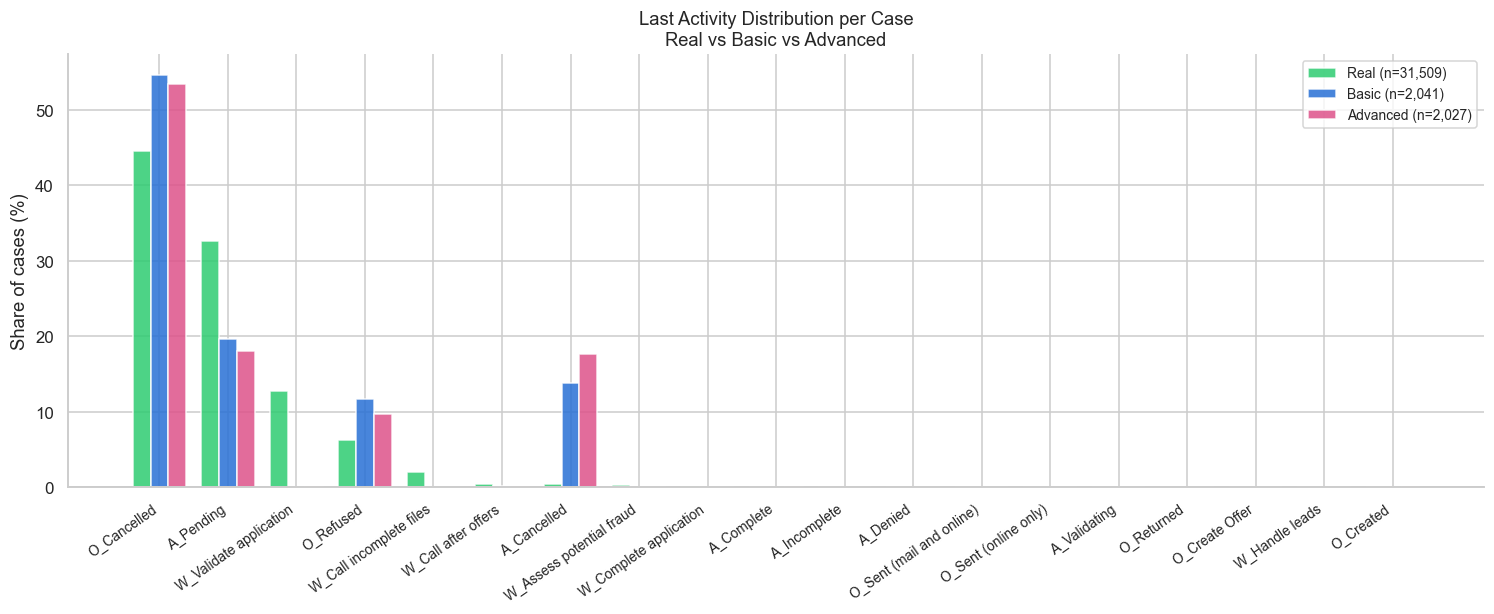

Saved -> results/metric4_last_activity_dist.png


In [69]:
# Last activity distribution — real log (all cases) vs Basic vs Advanced
# Real log includes right-censored cases (workflow activities as last event)
# which reveals how many cases were still in-flight when the log was cut off.

def last_activity_dist(df):
    last = (
        df.sort_values('time:timestamp')
          .groupby('case:concept:name')['concept:name']
          .last()
    )
    return last.value_counts(normalize=True) * 100

# Real log: filter to complete lifecycle events (as in validation section)
real_complete = real_df.copy()
if 'lifecycle:transition' in real_complete.columns:
    real_complete = real_complete[real_complete['lifecycle:transition'].str.lower() == 'complete']

real_last  = last_activity_dist(real_complete)
basic_last = last_activity_dist(basic_log)
adv_last   = last_activity_dist(advanced_log)

n_real  = real_complete['case:concept:name'].nunique()
n_basic = basic_log['case:concept:name'].nunique()
n_adv   = advanced_log['case:concept:name'].nunique()

# All activities sorted by real log frequency
all_last_acts = sorted(
    set(real_last.index) | set(basic_last.index) | set(adv_last.index),
    key=lambda a: -real_last.get(a, 0)
)

df_last = pd.DataFrame({
    'Activity':  all_last_acts,
    'Real (%)':  [real_last.get(a, 0)  for a in all_last_acts],
    'Basic (%)': [basic_last.get(a, 0) for a in all_last_acts],
    'Adv (%)':   [adv_last.get(a, 0)   for a in all_last_acts],
})
print(f"Last activity distribution  (Real n={n_real:,} | Basic n={n_basic:,} | Advanced n={n_adv:,})")
print(df_last.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_last_acts))
w = 0.26
ax.bar(x - w, [real_last.get(a, 0)  for a in all_last_acts], w,
       label=f'Real (n={n_real:,})', color=REAL_COLOR, alpha=0.85)
ax.bar(x,     [basic_last.get(a, 0) for a in all_last_acts], w,
       label=f'Basic (n={n_basic:,})', color=COLORS['basic'], alpha=0.85)
ax.bar(x + w, [adv_last.get(a, 0)   for a in all_last_acts], w,
       label=f'Advanced (n={n_adv:,})', color=COLORS['advanced'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_last_acts, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Share of cases (%)')
ax.set_title('Last Activity Distribution per Case\nReal vs Basic vs Advanced')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(pad=2.0)
plt.savefig(RESULTS_DIR / 'metric4_last_activity_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/metric4_last_activity_dist.png')

METRIC 4: OUTCOME DISTRIBUTION FIDELITY
  Real reference: 26,485 terminal cases / 31,509 total (84.1%)

  Outcome  Real (%)  Basic (%)  Advanced (%)
Cancelled      53.5       68.4          71.1
  Pending      38.8       19.6          18.0
  Refused       7.5       11.7           9.8
 Complete       0.1        0.0           0.2
 Accepted       0.0        0.0           0.0
   Denied       0.1        0.0           0.0
    Other       0.0        0.1           0.9

  JSD vs real — Basic: 0.1544  |  Advanced: 0.1735
  Fidelity   — Basic: 0.8456  |  Advanced: 0.8265
  Winner: Basic


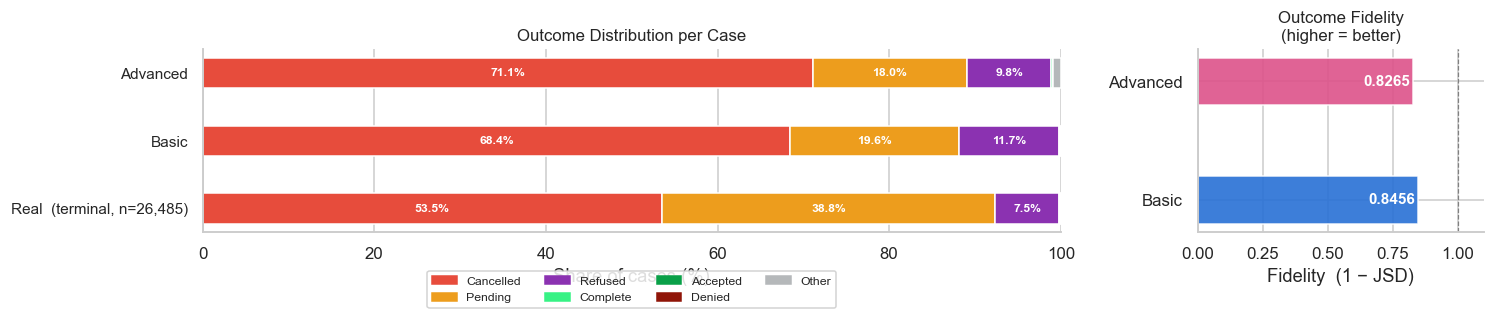

Saved -> results/metric4_outcome_fidelity.png


In [70]:
from scipy.spatial.distance import jensenshannon

# Fixed outcome categories
OUTCOME_CATEGORIES = ['Cancelled', 'Pending', 'Refused', 'Complete', 'Accepted', 'Denied', 'Other']

OUTCOME_COLORS = {
    'Cancelled': '#E74C3C',
    'Pending':   "#ED9D1D",
    'Refused':   "#8B32B1",
    'Complete':  "#37F285",
    'Accepted':  "#09A048",
    'Denied':    "#901508",
    'Other':     "#B5B8BA",
}

_LAST_ACT_OUTCOME = {
    'A_Complete':  'Complete',
    'A_Accepted':  'Accepted',
    'O_Accepted':  'Accepted',
    'A_Denied':    'Denied',
    'O_Refused':   'Refused',
    'A_Cancelled': 'Cancelled',
    'O_Cancelled': 'Cancelled',
    'A_Pending':   'Pending',
}
TERMINAL_ACTS = set(_LAST_ACT_OUTCOME.keys())

def classify_outcomes(df, terminal_filter=False):
    last = (
        df.sort_values('time:timestamp')
          .groupby('case:concept:name')['concept:name']
          .last()
    )
    if terminal_filter:
        last = last[last.isin(TERMINAL_ACTS)]
    return last.map(lambda a: _LAST_ACT_OUTCOME.get(a, 'Other'))

def outcome_dist(outcome_series):
    counts = outcome_series.value_counts()
    total = counts.sum()
    return {cat: counts.get(cat, 0) / total for cat in OUTCOME_CATEGORIES}

def jsd_outcomes(p, q):
    pv = np.array([p[k] for k in OUTCOME_CATEGORIES], dtype=float)
    qv = np.array([q[k] for k in OUTCOME_CATEGORIES], dtype=float)
    if pv.sum() > 0: pv /= pv.sum()
    if qv.sum() > 0: qv /= qv.sum()
    return float(jensenshannon(pv, qv))

# Real log complete lifecycle events, terminal cases only
real_complete = real_df.copy()
if 'lifecycle:transition' in real_complete.columns:
    real_complete = real_complete[real_complete['lifecycle:transition'].str.lower() == 'complete']

real_outcomes  = classify_outcomes(real_complete, terminal_filter=True)
basic_outcomes = classify_outcomes(basic_log,     terminal_filter=False)
adv_outcomes   = classify_outcomes(advanced_log,  terminal_filter=False)

n_real_terminal = len(real_outcomes)
n_real_total    = real_complete['case:concept:name'].nunique()

real_dist_out  = outcome_dist(real_outcomes)
basic_dist_out = outcome_dist(basic_outcomes)
adv_dist_out   = outcome_dist(adv_outcomes)

jsd_b = jsd_outcomes(real_dist_out, basic_dist_out)
jsd_a = jsd_outcomes(real_dist_out, adv_dist_out)
fidelity_b = 1 - jsd_b
fidelity_a = 1 - jsd_a

comp_df = pd.DataFrame({
    'Outcome':      OUTCOME_CATEGORIES,
    'Real (%)':     [real_dist_out[o] * 100  for o in OUTCOME_CATEGORIES],
    'Basic (%)':    [basic_dist_out[o] * 100 for o in OUTCOME_CATEGORIES],
    'Advanced (%)': [adv_dist_out[o] * 100   for o in OUTCOME_CATEGORIES],
})
print(f"METRIC 4: OUTCOME DISTRIBUTION FIDELITY")
print(f"  Real reference: {n_real_terminal:,} terminal cases / {n_real_total:,} total ({n_real_terminal/n_real_total*100:.1f}%)\n")
print(comp_df.round(1).to_string(index=False))
print(f"\n  JSD vs real — Basic: {jsd_b:.4f}  |  Advanced: {jsd_a:.4f}")
print(f"  Fidelity   — Basic: {fidelity_b:.4f}  |  Advanced: {fidelity_a:.4f}")
print(f"  Winner: {'Advanced' if jsd_a < jsd_b else 'Basic'}")

# Stacked horizontal bar
rows = [
    (f'Real  (terminal, n={n_real_terminal:,})', real_dist_out),
    ('Basic',    basic_dist_out),
    ('Advanced', adv_dist_out),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5),
                         gridspec_kw={'width_ratios': [3, 1]})

ax = axes[0]
bar_h = 0.45
for i, (label, dist) in enumerate(rows):
    left = 0.0
    for cat in OUTCOME_CATEGORIES:
        val = dist[cat] * 100
        bar = ax.barh(i, val, bar_h, left=left,
                      color=OUTCOME_COLORS[cat],
                      label=cat if i == 0 else '')
        if val >= 4:
            ax.text(left + val / 2, i, f'{val:.1f}%',
                    ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold')
        left += val

ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows], fontsize=10)
ax.set_xlabel('Share of cases (%)')
ax.set_xlim(0, 100)
ax.set_title('Outcome Distribution per Case', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
handles = [mpatches.Patch(color=OUTCOME_COLORS[c], label=c) for c in OUTCOME_CATEGORIES]
ax.legend(handles=handles, fontsize=8, ncol=4,
          loc='upper center', bbox_to_anchor=(0.5, -0.18),
          framealpha=0.85)

# Fidelity score panel
ax2 = axes[1]
fidelity_vals  = [fidelity_b, fidelity_a]
fidelity_labels = ['Basic', 'Advanced']
bars = ax2.barh(fidelity_labels, fidelity_vals,
                color=[COLORS['basic'], COLORS['advanced']], alpha=0.9, height=0.4)
for bar, val in zip(bars, fidelity_vals):
    ax2.text(val - 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', ha='right', va='center',
             fontsize=10, color='white', fontweight='bold')
ax2.set_xlim(0, 1.1)
ax2.axvline(1.0, color='grey', linestyle='--', lw=0.8)
ax2.set_xlabel('Fidelity  (1 − JSD)')
ax2.set_title('Outcome Fidelity\n(higher = better)', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig(RESULTS_DIR / 'metric4_outcome_fidelity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/metric4_outcome_fidelity.png')